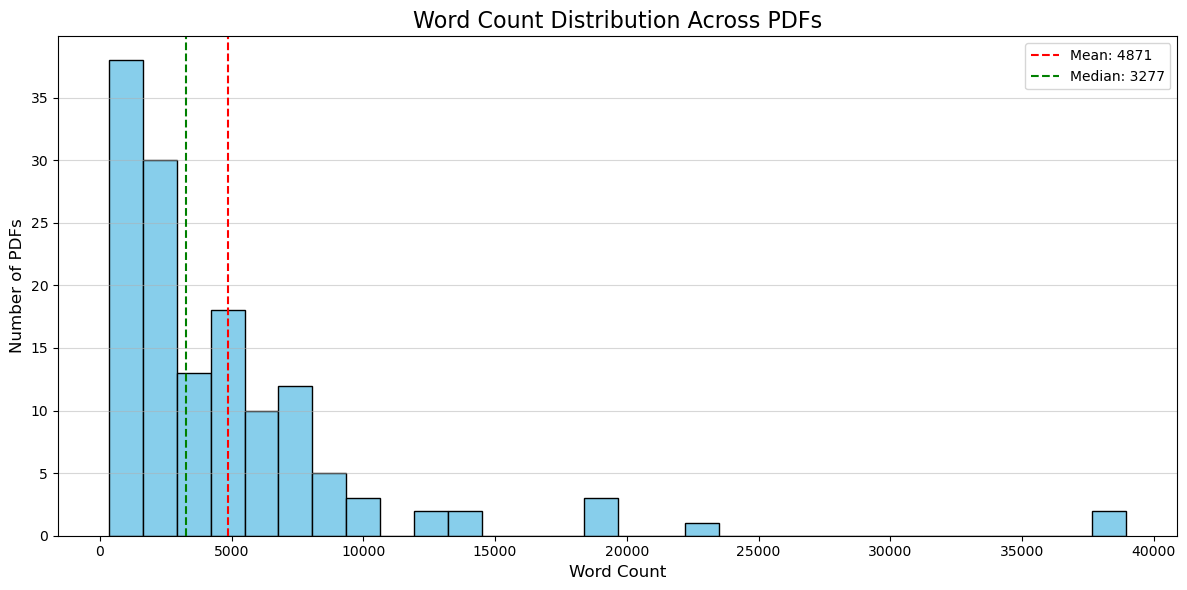

| Statistic   | Value (Words)   |
|:------------|:----------------|
| Count       | 139             |
| Mean        | 4,871           |
| Median      | 3,277           |
| Minimum     | 347             |
| Maximum     | 38,957          |
| 25th %ile   | 1,556           |
| 75th %ile   | 6,193           |
| Std Dev     | 5,780           |
| Skewness    | 3.6 (Right)     |
| Topic                                       |   Count |
|:--------------------------------------------|--------:|
| Capital Adequacy and Credit Risk Management |       3 |
| Credit Risks                                |      49 |
| Capital Adequacy                            |      26 |
| Market Risk Management                      |      25 |
| Liquidity Risks                             |      12 |
| Banks Security                              |      30 |


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('word_counts.csv')


# Plot histogram
plt.figure(figsize=(12, 6))
plt.hist(df["Word Count"], bins=30, color='skyblue', edgecolor='black')

# Customize the plot
plt.title("Word Count Distribution Across PDFs", fontsize=16)
plt.xlabel("Word Count", fontsize=12)
plt.ylabel("Number of PDFs", fontsize=12)
plt.grid(axis='y', alpha=0.5)

# Add mean/median lines
mean = df["Word Count"].mean()
median = df["Word Count"].median()
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.0f}')
plt.axvline(median, color='green', linestyle='--', label=f'Median: {median:.0f}')
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

# Calculate statistics
stats = df["Word Count"].describe(percentiles=[0.25, 0.75])
stats["skewness"] = df["Word Count"].skew()
stats["count"] = len(df)  # Override count (describe shows non-null)

# Format for readability
stats_formatted = {
    "Count": f"{int(stats['count']):,}",
    "Mean": f"{stats['mean']:,.0f}",
    "Median": f"{df['Word Count'].median():,.0f}",
    "Minimum": f"{stats['min']:,.0f}",
    "Maximum": f"{stats['max']:,.0f}",
    "25th %ile": f"{stats['25%']:,.0f}",
    "75th %ile": f"{stats['75%']:,.0f}",
    "Std Dev": f"{stats['std']:,.0f}",
    "Skewness": f"{stats['skewness']:.1f} (Right)"
}

# Convert to DataFrame for pretty display
stats_df = pd.DataFrame(list(stats_formatted.items()), columns=["Statistic", "Value (Words)"])
print(stats_df.to_markdown(index=False, tablefmt="pipe"))

from tabulate import tabulate
print(tabulate(data, headers="keys", tablefmt="pipe", showindex=False))